In [1]:
import pandas as pd
from tableone import tableone
center_map = {
    'BIDMC': 'Adult East', 
    'Stanford': 'Adult West', 
    'BCH': 'Pediatric East', 
    'CHLA': 'Pediatric West'
}
datasets = {
    'Stanford': {
        'filepath': 'data/from-r/stanford.csv',
        'col_map':{
            'gender':'sex',
            'csn':'id_visit',
            'x':'id_patient'
        }
    },
    'BIDMC': {
        'filepath': 'data/from-r/BIDMC-visits.csv',
        'race_cols': ['is_hispanic', 'is_black', 'is_asian', 'is_other'],
        'col_map':{
            'gender':'sex',
            'csn':'id_visit',
            'x':'id_patient',
            'acuity':'triage_acuity'
        }
    },
    'CHLA': {
        'filepath': 'data/from-r/CHLA.csv',
        'col_map':{
            'race_ethnicity':'race',
            'disposition':'is_admitted'
        }
    },
    'BCH': {
        'filepath': 'data/from-r/BCH.csv',
        'col_map':{
            'X':'id_patient',
            'csn': 'id_visit',
        }
    }  
}
race_map = {
    'hispanic':'Hispanic',
    'asian':'Asian', 
    'Non-Hispanic White': 'NH White',
    'Hispanic White':'Hispanic', 
    'Non-Hispanic Black': 'NH Black', 
    'White': 'NH White',
    'Black': 'NH Black', 
    'unknown':'Unknown', 
    'non_hispanic_white':'NH White', 
    'other':'Other',
    'non_hispanic_black':'NH Black'
    }
age_map = {
    'older_than_15_years':'15+', 
    'ten_to_15_years':'10-15', 
    'three_to_5_years':'3-5',
    'five_to_10_years': '5-10', 
    'under_3_months': '< 3 mo.', 
    'six_to_12_months': '6-12 mo.',
    'twelve_to_18_months': '12-18 mo.', 
    'three_to_6_months': '3-6 mo.',
    'eighteen_months_to_3_years': '1.5-3', 
    'fifteen_and_older':'15+'
}
frames = []
for dataset, v in datasets.items():
    print(dataset)
    f = v['filepath']
    df = (
        pd.read_csv(f)
        .rename(columns=v['col_map'])
        [[
            'id_visit',
            'id_patient',
            'age_group',
            'sex',
            'race',
            'triage_acuity',
            'is_admitted'
        ]]
        .rename(columns={'age_group':'Age Group','sex':'Sex','race':'Race','triage_acuity':'Triage Acuity'})
            
    )
    df['Disposition'] = df['is_admitted'].apply(lambda x: 'Admitted' if x==1 else 'Discharged' if x == 0 else x)
    df.loc[df['Disposition']=='Discharge','Disposition']='Discharged'
    df['Age Group'] = df['Age Group'].apply(lambda x: age_map[x] if x in age_map else x)
    df['Race'] = df['Race'].apply(lambda x: race_map[x] if x in race_map else x)
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    df['Center'] = center_map[dataset]
    frames.append(df)

df = pd.concat(frames).reset_index()

Stanford
BIDMC
CHLA


/var/folders/mw/j_dyskd90g71r91fkcf2v95h0000gn/T/ipykernel_8990/3611526329.py:73: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(f)


BCH


In [2]:
from tableone import TableOne
df['Disposition'].value_counts()
data = df
columns=[
    'Age Group',
    'Sex',
    'Race',
    'Triage Acuity',
    'Disposition',
]

categorical=[
    'Age Group',
    'Sex',
    'Race',
    'Triage Acuity',
    'Disposition',
]
groupby=[
    # 'Disposition'
    'Center'
]

mytable = TableOne(
    data, 
    columns=columns, 
    categorical=categorical, 
    groupby=groupby,
    order={'Age Group':[
        '< 3 mo.', 
        '3-6 mo.',
        '6-12 mo.', 
        '12-18 mo.', 
        '1.5-3',
        '3-5', 
        '5-10', 
        '10-15', 
        '15+',
        '18-29', 
        '30-39', 
        '60-69', 
        '70-79', 
        '40-49', 
        '50-59', 
        '80+', 
    ]},
    missing=False,
)

mytable.to_latex('paper/tables/table_one.tex', float_format="{{:_}}".format)
mytable

Grouped by Center                                                           
                                          Overall     Adult East    Adult West Pediatric East Pediatric West
n                                         1381873         398661        116063         339400         527749
Age Group, n (%)     < 3 mo.          35085 (2.5)                                 14178 (4.2)    20907 (4.0)
                     3-6 mo.          21869 (1.6)                                  9332 (2.7)    12537 (2.4)
                     6-12 mo.         56326 (4.1)                                 20089 (5.9)    36237 (6.9)
                     12-18 mo.        52066 (3.8)                                 18300 (5.4)    33766 (6.4)
                     1.5-3           115141 (8.3)                                41084 (12.1)   74057 (14.0)
                     3-5             115520 (8.4)                                40078 (11.8)   75442 (14.3)
                     5-10           197352 (14.3)                                69520 (20.5)  127832 (24.2)
                     10-15          142313 (10.3)                                58468 (17.2)   83845 (15.9)
                     15+             131477 (9.5)                                68351 (20.1)   63126 (12.0)
                     18-29            88749 (6.4)   70525 (17.7)  18224 (15.7)                              
                     30-39            68095 (4.9)   50214 (12.6)  17881 (15.4)                              
                     60-69            81313 (5.9)   63552 (15.9)  17761 (15.3)                              
                     70-79            63636 (4.6)   48618 (12.2)  15018 (12.9)                              
                     40-49            64769 (4.7)   49346 (12.4)  15423 (13.3)                              
                     50-59            84787 (6.1)   67493 (16.9)  17294 (14.9)                              
                     80+              63375 (4.6)   48913 (12.3)  14462 (12.5)                              
Sex, n (%)           F              687275 (49.7)  216552 (54.3)  63042 (54.3)  161725 (47.7)  245956 (46.6)
                     M              694598 (50.3)  182109 (45.7)  53021 (45.7)  177675 (52.3)  281793 (53.4)
Race, n (%)          Asian            70288 (5.1)    17661 (4.4)  18945 (16.3)    13260 (3.9)    20422 (3.9)
                     Hispanic       506986 (36.7)    32458 (8.1)  31943 (27.5)   88834 (26.2)  353751 (67.0)
                     NH Black       174044 (12.6)   86921 (21.8)    7296 (6.3)   50853 (15.0)    28974 (5.5)
                     NH White       425064 (30.8)  232435 (58.3)  43101 (37.1)  116339 (34.3)    33189 (6.3)
                     Other          144290 (10.4)    23622 (5.9)  13839 (11.9)    33639 (9.9)   73190 (13.9)
                     Unknown          61201 (4.4)     5564 (1.4)     939 (0.8)   36475 (10.7)    18223 (3.5)
Triage Acuity, n (%) 1.0              27887 (2.0)    22975 (5.8)    1029 (0.9)     1535 (0.5)     2348 (0.4)
                     2.0            321814 (23.4)  130564 (33.2)  27312 (23.6)   83163 (24.5)   80775 (15.3)
                     3.0            593045 (43.1)  211668 (53.9)  75717 (65.5)  159571 (47.1)  146089 (27.7)
                     4.0            302683 (22.0)    26855 (6.8)   10830 (9.4)   85969 (25.4)  179029 (33.9)
                     5.0             129673 (9.4)      955 (0.2)     668 (0.6)     8811 (2.6)  119239 (22.6)
Disposition, n (%)   Admitted       309794 (22.4)  157514 (39.5)  31574 (27.2)   60843 (17.9)   59863 (11.3)
                     Discharged    1069915 (77.4)  241147 (60.5)  84489 (72.8)  278557 (82.1)  465722 (88.2)
                     Transfer          2164 (0.2)                                                 2164 (0.4)

In [3]:
data.groupby('Center')['id_patient'].nunique()

Center
Adult East        398661
Adult West        116063
Pediatric East    339400
Pediatric West    239726
Name: id_patient, dtype: int64

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


<Axes: xlabel='Triage Acuity', ylabel='Proportion'>

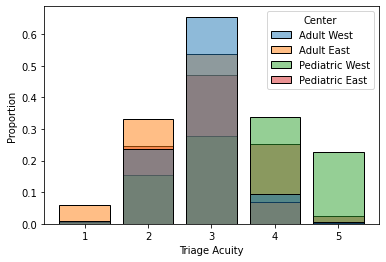

In [4]:
import seaborn as sns

df_plt = data

sns.histplot(
    data=df_plt,
    x='Triage Acuity',
    hue='Center',
    fill=True,
    common_norm=False,
    multiple='layer',
    shrink=0.8,
    discrete=True,
    element='bars',
    stat='proportion'
    
)

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


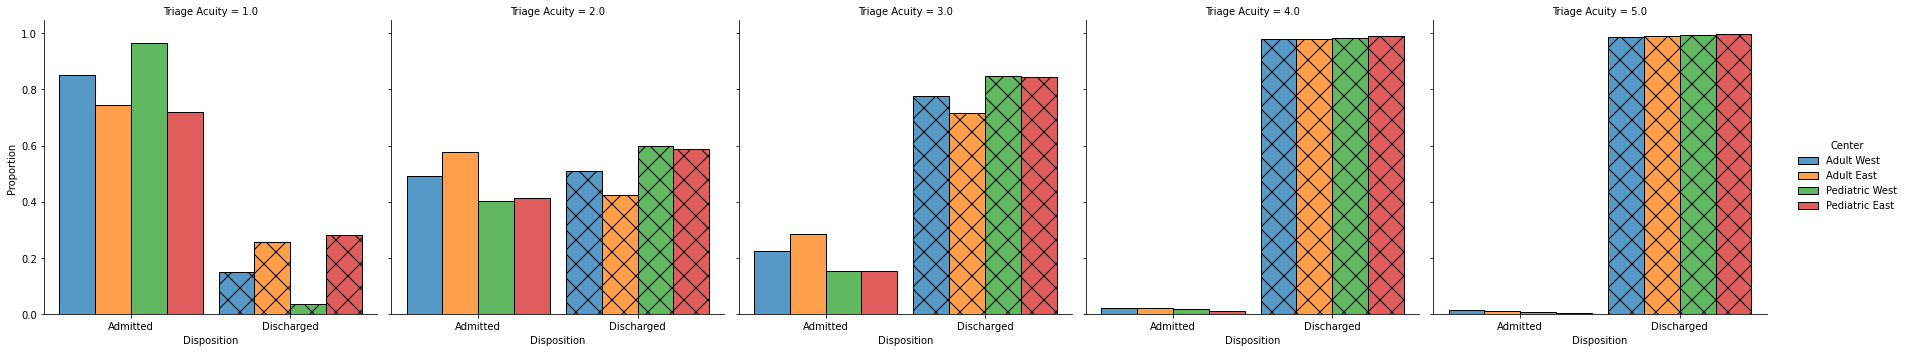

In [5]:
import seaborn as sns

df_plt = data[data.Disposition.isin(['Admitted','Discharged'])]

g = sns.displot(
    kind='hist',
    stat='proportion',
    data=df_plt,
    x='Disposition',
    discrete=True,
    # order=['Admitted'],
    col='Triage Acuity',
    hue='Center',
    multiple='dodge',
    # multiple='stack',
    common_norm=False,
    shrink=0.9
)
for k,ax in g.axes_dict.items():
    bars = [
        # ax.patches[0],
        ax.patches[1],
        # ax.patches[2],
        ax.patches[3],
        # ax.patches[4],
        ax.patches[5],
        # ax.patches[6],
        ax.patches[7]
    ]
    for bar in bars:
        bar.set_hatch('x')

/var/folders/mw/j_dyskd90g71r91fkcf2v95h0000gn/T/ipykernel_8990/2642538685.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plt.loc[:,'Admitted'] = (df_plt['Disposition'].values=='Admitted').astype(float)*100


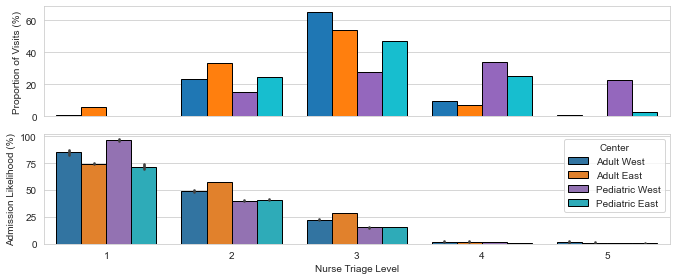

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
# sns.set_theme('paper',style='whitegrid')
sns.set_style('whitegrid')
df_plt = data[data.Disposition.isin(['Admitted','Discharged'])]
df_plt.loc[:,'Admitted'] = (df_plt['Disposition'].values=='Admitted').astype(float)*100
# df_plt['Admitted'] = df_plt['Admitted']/len(df_plt)
df_plt = df_plt[~df_plt['Triage Acuity'].isnull()]
df_plt['Triage Acuity'] = df_plt['Triage Acuity'].astype(int)

fig, axes = plt.subplots(2,1, figsize=(9.5,4))

palette_map = {
    'Adult West': '#1F77B4',
    'Adult East': '#FF7F0E',
    'Pediatric West': '#9467BD',
    'Pediatric East': '#17BECF',
}
ax1 = sns.histplot(
    element='bars',
    data=df_plt,
    ax=axes[0],
    stat='percent',
    # y='Admitted',
    discrete=True,
    # order=['Admitted'],
    x='Triage Acuity',
    hue='Center',
    multiple='dodge',
    # multiple='stack',
    common_norm=False,
    shrink=0.8,
    alpha=1,
    edgecolor='k',
    legend=False,
    palette=palette_map
)
ax1.set_xlabel('')
# ax1.set_xlim(
ax1.set_xticklabels([])
from matplotlib.colors import ListedColormap
ax2 = sns.barplot(
    # stat='proportion',
    data=df_plt,
    ax=axes[1],
    y='Admitted',
    # discrete=True,
    # order=['Admitted'],
    x='Triage Acuity',
    hue='Center',
    # multiple='dodge',
    # multiple='stack',
    # common_norm=False,
    # shrink=0.9,
    edgecolor='k',
    linewidth=1.0,
    palette=palette_map
)
ax1.set_xlim((0.5, 5.5))
ax2.set_xlim((-0.5, 4.5))
ax2.set_xlabel('Nurse Triage Level')
ax1.set_ylabel('Proportion of Visits (%)')
ax2.set_ylabel('Admission Likelihood (%)')
ax1.grid(visible=True,axis='y')
ax1.grid(visible=False,axis='x')
ax2.grid(visible=True,axis='y')
fig.tight_layout()
# for k,ax in g.axes_dict.items():
#     bars = [
#         # ax.patches[0],
#         ax.patches[1],
#         # ax.patches[2],
#         ax.patches[3],
#         # ax.patches[4],
#         ax.patches[5],
#         # ax.patches[6],
#         ax.patches[7]
#     ]
#     for bar in bars:
#         bar.set_hatch('x')
fig.savefig('paper/figures/barplot_triage_assignment_admission.pdf', dpi=400, bbox_inches='tight')

In [ ]:
fig.get_size_inches()

In [ ]:
df_plt['Disposition'].values=='Admitted'